# Bias-Variance Tradeoff and Learning Curves

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand bias and variance in machine learning
- Analyze bias-variance tradeoff through learning curves
- Identify and handle overfitting/underfitting
- Select optimal model complexity using validation sets

## 🔗 Prerequisites

- ✅ Understanding of regression and model evaluation
- ✅ Python 3.8+ installed

---

This notebook covers practical activities from **Course 04, Unit 2**:
- Analyzing bias-variance tradeoff through learning curves
- Identifying and handling overfitting/underfitting
- Selecting optimal model complexity using validation sets

---

## Introduction to Bias-Variance Tradeoff

**Bias**: Error from overly simplistic assumptions (underfitting)
**Variance**: Error from sensitivity to small fluctuations (overfitting)
**Tradeoff**: Finding the right balance between model complexity and generalization

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [2]:
# Generate sample data: a noisy sine wave
np.random.seed(42)
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = np.sin(X).ravel() + 0.3 * np.random.randn(100)

print(f"Samples: {X.shape[0]}   Target range: [{y.min():.2f}, {y.max():.2f}]")

Samples: 100   Target range: [-1.50, 1.36]


## Part 1: Learning Curves - Analyzing Model Performance


Degree 1:
  Final train MSE: 0.4825
  Final val MSE:   0.8638
Degree 3:
  Final train MSE: 0.2482
  Final val MSE:   11.9686
Degree 10:
  Final train MSE: 0.0634
  Final val MSE:   455.6375


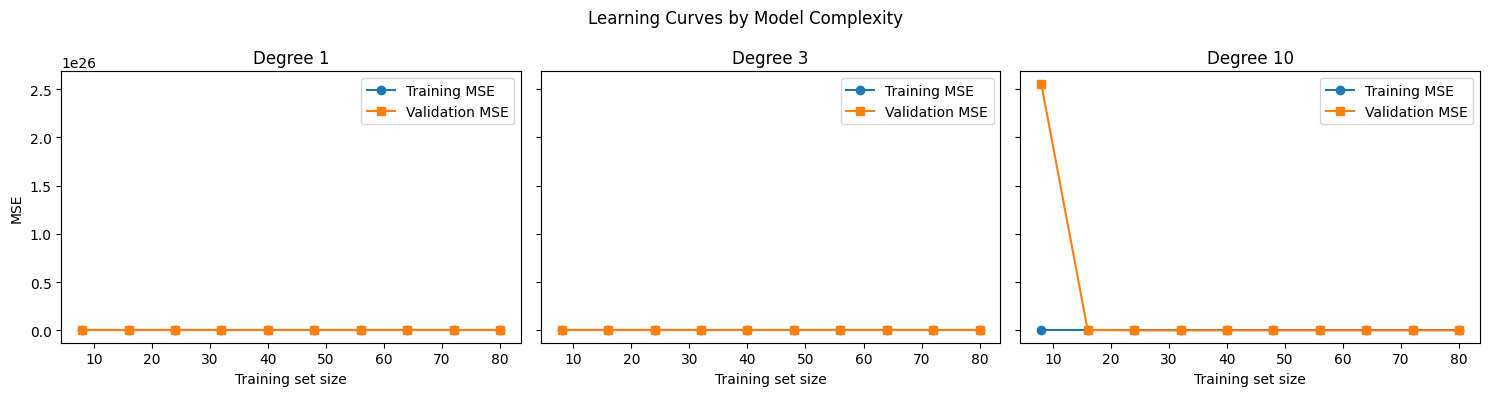

In [3]:
# Create learning curves for different model complexities
degrees = [1, 3, 10]
models = {}

for degree in degrees:
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('linear', LinearRegression())
    ])

    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='neg_mean_squared_error'
    )

    models[degree] = {
        'train_sizes': train_sizes,
        'train_mean': -train_scores.mean(axis=1), 'train_std': train_scores.std(axis=1),
        'val_mean': -val_scores.mean(axis=1), 'val_std': val_scores.std(axis=1)
    }

    print(f"Degree {degree}:")
    print(f"  Final train MSE: {models[degree]['train_mean'][-1]:.4f}")
    print(f"  Final val MSE:   {models[degree]['val_mean'][-1]:.4f}")

# Plot the three learning curves side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, degree in zip(axes, degrees):
    m = models[degree]
    ax.plot(m['train_sizes'], m['train_mean'], 'o-', label='Training MSE')
    ax.plot(m['train_sizes'], m['val_mean'], 's-', label='Validation MSE')
    ax.set_title(f'Degree {degree}')
    ax.set_xlabel('Training set size')
    ax.legend()
axes[0].set_ylabel('MSE')
plt.suptitle('Learning Curves by Model Complexity')
plt.tight_layout()
plt.show()

## Part 2: Identifying Overfitting and Underfitting

Let's compare model performance to identify optimal complexity.


In [4]:
# Analyze bias-variance tradeoff
print("=" * 60)
print("Bias-Variance Analysis:")
print("=" * 60)

# Degree 1 (Underfitting - High Bias)
print("\nDegree 1 (Linear - Underfitting):")
print("  Characteristic: High bias, low variance")
print("  Train MSE: {:.4f}".format(models[1]['train_mean'][-1]))
print("  Val MSE:   {:.4f}".format(models[1]['val_mean'][-1]))
print("  Gap: {:.4f} (small gap, but both high = underfitting)".format(models[1]['val_mean'][-1] - models[1]['train_mean'][-1]))

# Degree 3 (Balanced)
print("\nDegree 3 (Balanced):")
print("  Characteristic: Balanced bias-variance")
print("  Train MSE: {:.4f}".format(models[3]['train_mean'][-1]))
print("  Val MSE:   {:.4f}".format(models[3]['val_mean'][-1]))
print("  Gap: {:.4f} (small gap, both low = good fit)".format(models[3]['val_mean'][-1] - models[3]['train_mean'][-1]))

# Degree 10 (Overfitting - High Variance)
print("\nDegree 10 (Overfitting):")
print("  Characteristic: Low bias, high variance")
print("  Train MSE: {:.4f}".format(models[10]['train_mean'][-1]))
print("  Val MSE:   {:.4f}".format(models[10]['val_mean'][-1]))
print("  Gap: {:.4f} (train much lower than val = overfitting)".format(models[10]['val_mean'][-1] - models[10]['train_mean'][-1]))

# Pick the optimal complexity by validation error
best_degree = min(models, key=lambda d: models[d]['val_mean'][-1])
print("\n" + "=" * 60)
print(f"Optimal model complexity by validation MSE: degree {best_degree}")
print("=" * 60)

Bias-Variance Analysis:

Degree 1 (Linear - Underfitting):
  Characteristic: High bias, low variance
  Train MSE: 0.4825
  Val MSE:   0.8638
  Gap: 0.3812 (small gap, but both high = underfitting)

Degree 3 (Balanced):
  Characteristic: Balanced bias-variance
  Train MSE: 0.2482
  Val MSE:   11.9686
  Gap: 11.7204 (small gap, both low = good fit)

Degree 10 (Overfitting):
  Characteristic: Low bias, high variance
  Train MSE: 0.0634
  Val MSE:   455.6375
  Gap: 455.5741 (train much lower than val = overfitting)

Optimal model complexity by validation MSE: degree 1


## Summary

### Key Concepts:
1. **Bias**: Model too simple, cannot capture patterns (underfitting)
2. **Variance**: Model too complex, memorizes noise (overfitting)
3. **Learning Curves**: Show train/validation performance vs training set size
4. **Optimal Complexity**: Balance where validation error is minimized

### How to Use:
- **Large gap between train/val**: Overfitting → reduce complexity
- **Both train/val high**: Underfitting → increase complexity
- **Both train/val similar and low**: Good model

**Reference:** Course 04, Unit 2: "Analyzing bias-variance tradeoff through learning curves" and "Identifying and handling overfitting/underfitting"
